In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load the dataset
cancer = load_breast_cancer()
data = pd.DataFrame(cancer['data'], columns=cancer['feature_names'])
data['y'] = cancer['target']  # Append the target column to the DataFrame

# Display the first few rows of the dataset
print(data.head())


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load the dataset
cancer = load_breast_cancer()
data = pd.DataFrame(cancer['data'], columns=cancer['feature_names'])
data['y'] = cancer['target']  # Append the target column to the DataFrame

# Display the first 3 rows and the last row of the dataset
print(data.head(3))
print(data.iloc[-1])


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0          0.11840   
1        20.57         17.77           132.9     1326.0          0.08474   
2        19.69         21.25           130.0     1203.0          0.10960   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0                 0.07871  ...          17.33            184.6      2019.0   
1                 0.05667  ...          23.41            158.8      1956.0   
2                 0.05999  ...          25.53            152.5      1709.0   

   worst smoothness  worst compactness  worst concavity  worst concave points  \


原始特征数量: 13
降维后的特征数量: 3
解释方差比率每主成分： [0.628, 0.136, 0.056]
累积解释方差： [0.628, 0.765, 0.821]


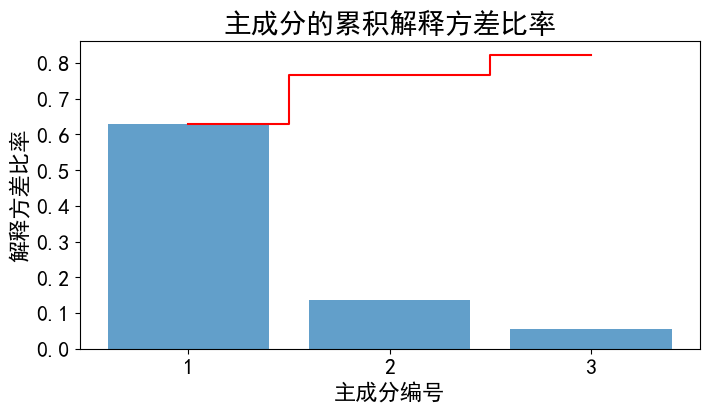

D:\anconada\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


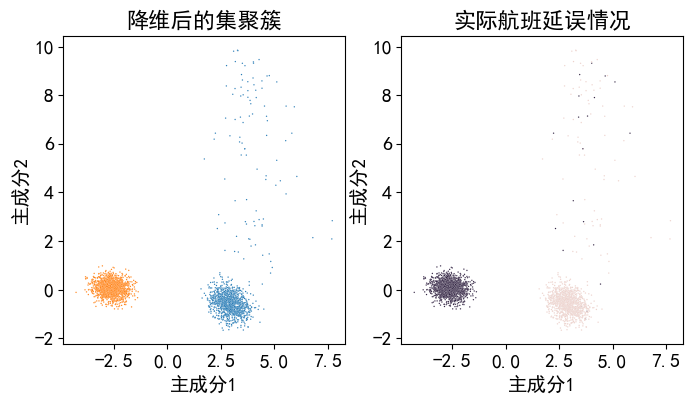

In [13]:
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# 设置环境变量以避免内存泄漏
os.environ['OMP_NUM_THREADS'] = '10'

# 设置字体为黑体，确保该字体在你的系统中是可用的
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 1. 加载数据
data = pd.read_excel('aircraftFlightDelay.xlsx')
data = data.dropna()  # 去除缺失值
data.drop(['ID'], axis=1, inplace=True)  # 删除不需要的列

# 2. 标准化数据
scaler = StandardScaler()
scaled_data = pd.DataFrame(data=scaler.fit_transform(data.iloc[:, :-1]), columns=data.columns[:-1])

# 3. 应用PCA
pca = PCA(n_components=0.8)  # 选择解释80%以上的方差
principal_components = pca.fit_transform(scaled_data)
principal_df = pd.DataFrame(data=principal_components, columns=[f'Principal Component {i + 1}' for i in range(principal_components.shape[1])])  # 将PCA结果转换为DataFrame
explained_variance_ratio = pca.explained_variance_ratio_  # 每个主成分的解释方差比率
cumulative_variance = explained_variance_ratio.cumsum()  # 显示累积解释的方差比率

# 4. 打印结果
print("原始特征数量:", scaled_data.shape[1])
print("降维后的特征数量:", principal_components.shape[1])
print("解释方差比率每主成分：", [round(var, 3) for var in explained_variance_ratio])
print("累积解释方差：", [round(var, 3) for var in cumulative_variance])

# 5. 可视化累积解释方差比率
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, align='center')  # 创建条形图表示每个主成分的解释方差比率
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', color='r')  # 添加阶梯线表示累积解释方差比率
plt.title('主成分的累积解释方差比率', fontsize=20)
plt.xlabel('主成分编号', fontsize=16)
plt.ylabel('解释方差比率', fontsize=16)
plt.xticks(range(1, len(explained_variance_ratio) + 1), fontsize=16)  # 设置x轴标记为整数
plt.yticks(fontsize=16)  # 设置y轴标记
plt.show()  # 显示图表

# 6. 可视化降维效果
plt.figure(figsize=(8, 4))
plt.subplot(121)  # 绘制子图1
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
principal_df['cluster'] = clusters
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='cluster', data=principal_df, s=1, legend=False)
plt.title('降维后的集聚簇', fontsize=16)
plt.xlabel('主成分1', fontsize=14)
plt.ylabel('主成分2', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.subplot(122)  # 绘制子图2
principal_df['label'] = data.iloc[:, -1]
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='label', data=principal_df, s=1, legend=False)
plt.title('实际航班延误情况', fontsize=16)
plt.xlabel('主成分1', fontsize=14)
plt.ylabel('主成分2', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()  # 显示图表

原始特征数量: 13
降维后的特征数量: 3
解释方差比率每主成分： [0.628, 0.136, 0.056]
累积解释方差： [0.628, 0.765, 0.821]


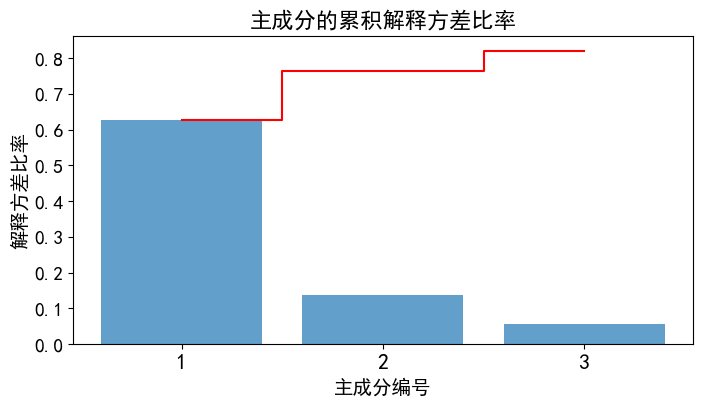

D:\anconada\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


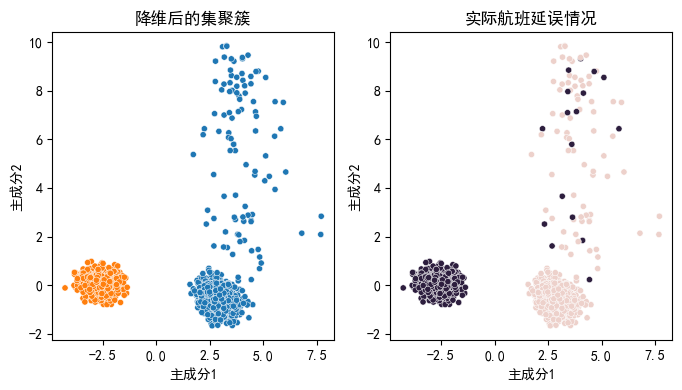

In [11]:
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# 设置环境变量以避免内存泄漏
os.environ['OMP_NUM_THREADS'] = '10'

# 设置字体为黑体，确保该字体在你的系统中是可用的
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 1. 加载数据
data = pd.read_excel('aircraftFlightDelay.xlsx')
data = data.dropna()  # 去除缺失值
data.drop(['ID'], axis=1, inplace=True)  # 删除不需要的列

# 2. 标准化数据
scaler = StandardScaler()
scaled_data = pd.DataFrame(data=scaler.fit_transform(data.iloc[:, :-1]), columns=data.columns[:-1])

# 3. 应用PCA
pca = PCA(n_components=0.8)  # 选择解释80%以上的方差
principal_components = pca.fit_transform(scaled_data)
principal_df = pd.DataFrame(data=principal_components, columns=[f'Principal Component {i + 1}' for i in range(principal_components.shape[1])])  # 将PCA结果转换为DataFrame
explained_variance_ratio = pca.explained_variance_ratio_  # 每个主成分的解释方差比率
cumulative_variance = explained_variance_ratio.cumsum()  # 显示累积解释的方差比率

# 4. 打印结果
print("原始特征数量:", scaled_data.shape[1])
print("降维后的特征数量:", principal_components.shape[1])
print("解释方差比率每主成分：", [round(var, 3) for var in explained_variance_ratio])
print("累积解释方差：", [round(var, 3) for var in cumulative_variance])

# 5. 可视化累积解释方差比率
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, align='center')  # 创建条形图表示每个主成分的解释方差比率
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', color='r')  # 添加阶梯线表示累积解释方差比率
plt.title('主成分的累积解释方差比率', fontsize=16)
plt.xlabel('主成分编号', fontsize=14)
plt.ylabel('解释方差比率', fontsize=14)
plt.xticks(range(1, len(explained_variance_ratio) + 1), fontsize=16)  # 设置x轴标记为整数
plt.yticks(fontsize=14)  # 设置y轴标记
plt.show()  # 显示图表
# 6. 可视化降维效果
plt.figure(figsize=(8, 4))
plt.subplot(121)  # 绘制子图1
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
principal_df['cluster'] = clusters
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='cluster', data=principal_df, s=20, legend=False)
plt.title('降维后的集聚簇')
plt.xlabel('主成分1')
plt.ylabel('主成分2')
plt.subplot(122)  # 绘制子图2
principal_df['label'] = data.iloc[:, -1]
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='label', data=principal_df, s=20, legend=False)
plt.title('实际航班延误情况')
plt.xlabel('主成分1')
plt.ylabel('主成分2')
plt.show()  # 显示图表

原始特征数量: 13
降维后的特征数量: 3
解释方差比率每主成分： [0.628, 0.136, 0.056]
累积解释方差： [0.628, 0.765, 0.821]


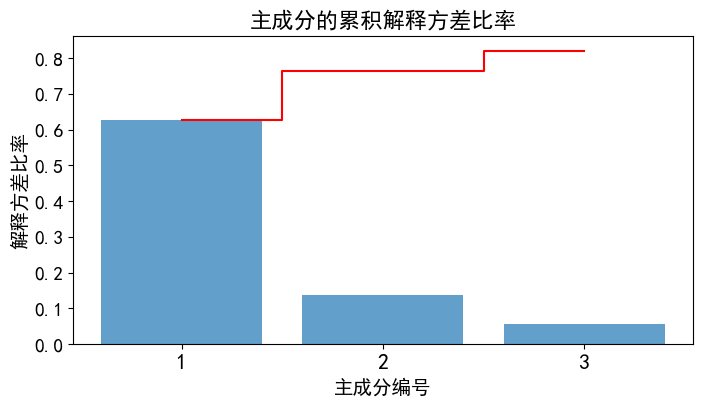

D:\anconada\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


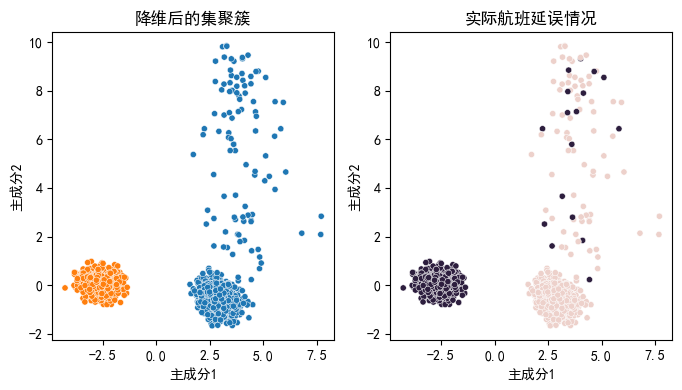

In [1]:
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# 设置环境变量以避免内存泄漏
os.environ['OMP_NUM_THREADS'] = '10'

# 设置字体为黑体，确保该字体在你的系统中是可用的
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 1. 加载数据
data = pd.read_excel('aircraftFlightDelay.xlsx')
data = data.dropna()  # 去除缺失值
data.drop(['ID'], axis=1, inplace=True)  # 删除不需要的列

# 2. 标准化数据
scaler = StandardScaler()
scaled_data = pd.DataFrame(data=scaler.fit_transform(data.iloc[:, :-1]), columns=data.columns[:-1])

# 3. 应用PCA
pca = PCA(n_components=0.8)  # 选择解释80%以上的方差
principal_components = pca.fit_transform(scaled_data)
principal_df = pd.DataFrame(data=principal_components, columns=[f'Principal Component {i + 1}' for i in range(principal_components.shape[1])])  # 将PCA结果转换为DataFrame
explained_variance_ratio = pca.explained_variance_ratio_  # 每个主成分的解释方差比率
cumulative_variance = explained_variance_ratio.cumsum()  # 显示累积解释的方差比率

# 4. 打印结果
print("原始特征数量:", scaled_data.shape[1])
print("降维后的特征数量:", principal_components.shape[1])
print("解释方差比率每主成分：", [round(var, 3) for var in explained_variance_ratio])
print("累积解释方差：", [round(var, 3) for var in cumulative_variance])

# 5. 可视化累积解释方差比率
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, align='center')  # 创建条形图表示每个主成分的解释方差比率
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', color='r')  # 添加阶梯线表示累积解释方差比率
plt.title('主成分的累积解释方差比率', fontsize=16)
plt.xlabel('主成分编号', fontsize=14)
plt.ylabel('解释方差比率', fontsize=14)
plt.xticks(range(1, len(explained_variance_ratio) + 1), fontsize=16)  # 设置x轴标记为整数
plt.yticks(fontsize=14)  # 设置y轴标记
plt.savefig('F:\\zhoumian\\《大数据·Python编程基础》_5数据挖掘\\矢量图片\\25.1主成分分析图.svg', format='svg')  # 保存为矢量图
plt.show()  # 显示图表

# 6. 可视化降维效果
plt.figure(figsize=(8, 4))
plt.subplot(121)  # 绘制子图1
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
principal_df['cluster'] = clusters
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='cluster', data=principal_df, s=20, legend=False)
plt.title('降维后的集聚簇')
plt.xlabel('主成分1')
plt.ylabel('主成分2')
plt.subplot(122)  # 绘制子图2
principal_df['label'] = data.iloc[:, -1]
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='label', data=principal_df, s=20, legend=False)
plt.title('实际航班延误情况')
plt.xlabel('主成分1')
plt.ylabel('主成分2')
plt.savefig('F:\\zhoumian\\《大数据·Python编程基础》_5数据挖掘\\矢量图片\\25.1降维效果分析图.svg', format='svg')  # 保存为矢量图
plt.show()  # 显示图表